In [1]:
import os
import json
import zlib
import base64
import numpy as np
from PIL import Image
from io import BytesIO
from torch.utils.data import Dataset
import torchvision.transforms as T


class CIHPDataset(Dataset):
    def __init__(self, root_dir, target_classes=None, transform=None, target_size=(512, 512)):
        self.img_dir = os.path.join(root_dir, 'img')
        self.ann_dir = os.path.join(root_dir, 'ann')
        self.filenames = sorted(f for f in os.listdir(self.img_dir) if f.endswith('.jpg'))
        self.target_classes = target_classes or ['face', 'head']
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        image_path = os.path.join(self.img_dir, filename)
        ann_path = os.path.join(self.ann_dir, filename + '.json')

        image = Image.open(image_path).convert('RGB')
        mask = self._load_mask_from_json(ann_path, image.size)

        # Resize
        image = image.resize(self.target_size, Image.BILINEAR)
        mask = mask.resize(self.target_size, Image.NEAREST)

        # To tensor
        image = T.ToTensor()(image)
        mask = np.array(mask, dtype=np.int64)

        return image, mask

    def _load_mask_from_json(self, ann_path, image_size):
        width, height = image_size
        mask = Image.new('L', (width, height), 0)

        with open(ann_path, 'r') as f:
            data = json.load(f)

        for obj in data.get('objects', []):
            class_title = obj.get('classTitle', '').lower()
            if class_title not in self.target_classes:
                continue

            if obj.get('geometryType') != 'bitmap':
                continue

            bitmap = obj['bitmap']
            origin_x, origin_y = bitmap['origin']
            b64_data = bitmap['data']
            raw = zlib.decompress(base64.b64decode(b64_data))
            submask = Image.open(BytesIO(raw)).convert('L')

            # Paste submask into full image mask
            mask.paste(1, box=(origin_x, origin_y), mask=submask)

        return mask


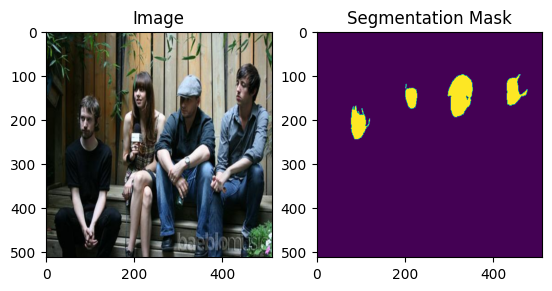

In [4]:
dataset = CIHPDataset('training', target_classes=['face', 'hat', 'head'])
image, mask = dataset[1]

# Show it
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1); plt.imshow(image.permute(1, 2, 0)); plt.title("Image")
plt.subplot(1, 2, 2); plt.imshow(mask); plt.title("Segmentation Mask")
plt.show()


In [2]:
# cihp_training_pipeline.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import torchvision.transforms as T
from tqdm import tqdm

# --- Config ---
ROOT_DIR = 'training'  # 'validation' or 'testing' for val/test
TARGET_CLASSES = ['face', 'hat']  # define classes you care about
NUM_CLASSES = len(TARGET_CLASSES) + 1  # +1 for background
BATCH_SIZE = 4
NUM_EPOCHS = 20
IMG_SIZE = (512, 512)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from torch.utils.data import Subset
import random


# --- Dataset ---
train_dataset = CIHPDataset(
    root_dir=ROOT_DIR,
    target_classes=TARGET_CLASSES,
    target_size=IMG_SIZE
)
subset_size = 500
indices = random.sample(range(len(train_dataset)), subset_size)
train_subset = Subset(train_dataset, indices)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# --- Model ---
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

# --- Loss + Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Training Loop ---
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)['out']  # shape: [B, C, H, W]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# --- Save Model ---
torch.save(model.state_dict(), 'deeplabv3_cihp.pth')
print("Training complete. Model saved.")


C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alexi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Epoch 1/20: 100%|██████████| 125/125 [00:39<00:00,  3.15it/s]


Epoch 1, Loss: 0.4047


Epoch 2/20: 100%|██████████| 125/125 [00:24<00:00,  5.06it/s]


Epoch 2, Loss: 0.1461


Epoch 3/20: 100%|██████████| 125/125 [00:23<00:00,  5.28it/s]


...

Epoch 18, Loss: 0.0246


Epoch 19/20: 100%|██████████| 125/125 [00:21<00:00,  5.94it/s]


Epoch 19, Loss: 0.0233


Epoch 20/20: 100%|██████████| 125/125 [00:21<00:00,  5.82it/s]

Epoch 20, Loss: 0.0225
Training complete. Model saved.


In [9]:
# cihp_training_pipeline.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import models
import torchvision.transforms as T
from tqdm import tqdm
import random

# --- Config ---
ROOT_DIR = 'training'
TARGET_CLASSES = ['face', 'hat']
NUM_CLASSES = len(TARGET_CLASSES) + 1
BATCH_SIZE = 4
NUM_EPOCHS = 20
IMG_SIZE = (512, 512)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Dataset ---
train_dataset = CIHPDataset(
    root_dir=ROOT_DIR,
    target_classes=TARGET_CLASSES,
    target_size=IMG_SIZE
)

# --- Model ---
model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model = model.to(DEVICE)

# --- Loss + Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# --- Training Loop ---
for epoch in range(NUM_EPOCHS):
    # Create a new random subset of 125 unique samples each epoch
    subset_size = 500
    indices = random.sample(range(len(train_dataset)), subset_size)
    sampler = SubsetRandomSampler(indices)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)

    model.train()
    running_loss = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)['out']
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# --- Save Model ---
torch.save(model.state_dict(), 'deeplabv3_cihp_2.pth')
print("Training complete. Model saved.")


Epoch 1/20: 100%|██████████| 125/125 [00:36<00:00,  3.43it/s]


Epoch 1, Loss: 0.4136


Epoch 2/20: 100%|██████████| 125/125 [00:35<00:00,  3.51it/s]


Epoch 2, Loss: 0.1513


Epoch 3/20: 100%|██████████| 125/125 [00:34<00:00,  3.60it/s]


...

Epoch 18, Loss: 0.0561


Epoch 19/20: 100%|██████████| 125/125 [00:38<00:00,  3.25it/s]


Epoch 19, Loss: 0.0478


Epoch 20/20: 100%|██████████| 125/125 [00:37<00:00,  3.33it/s]

Epoch 20, Loss: 0.0487
Training complete. Model saved.


In [14]:
from torchvision import models
import torch
import torch.nn as nn

NUM_CLASSES = 3  # background + face + hat (match training)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = models.segmentation.deeplabv3_mobilenet_v3_large(pretrained=False)
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
model.load_state_dict(torch.load('deeplabv3_cihp.pth', map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

from PIL import Image
import torchvision.transforms as T

def preprocess_image(img_path, img_size=(512, 512)):
    image = Image.open(img_path).convert('RGB')
    original_size = image.size
    image = image.resize(img_size, Image.BILINEAR)
    tensor = T.ToTensor()(image).unsqueeze(0).to(DEVICE)
    return tensor, original_size

import torch.nn.functional as F

def predict_mask(model, input_tensor, original_size):
    with torch.no_grad():
        output = model(input_tensor)['out']
        logits = F.interpolate(output, size=original_size[::-1], mode='bilinear', align_corners=False)
        predicted = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return predicted  # shape: (H, W), values: 0 (bg), 1 (face), 2 (hat)

import cv2
import numpy as np

def count_faces(mask, face_class=1):
    face_mask = (mask == face_class).astype(np.uint8)
    num_labels, labels_im = cv2.connectedComponents(face_mask)
    return num_labels - 1  # subtract background


image_path = 'istockphoto-1480574526-612x612.jpg'  # replace with your image path
tensor, original_size = preprocess_image(image_path)
mask = predict_mask(model, tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")



C:\Users\alexi\AppData\Local\Temp\ipykernel_20560\2072873065.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('deeplabv3_cihp.pth', map_

Detected 14 face(s).


In [13]:
image, _ = dataset[1]  # Already resized & tensorized
input_tensor = image.unsqueeze(0).to(DEVICE)  # Add batch dim
original_size = (image.shape[2], image.shape[1])  # (W, H) from tensor shape

mask = predict_mask(model, input_tensor, original_size)
num_faces = count_faces(mask)

print(f"Detected {num_faces} face(s).")


Detected 4 face(s).
